**Backtesting Moving Averages**

In [10]:
import yfinance as yf
import pandas as pd
import plotly as plt

start = '2020-01-01'
end = '2026-01-01'
ticker = ['AAPL', 'TSLA', 'META', 'GOOGL', 'AVGO', 'MSFT', 'MA', 'WMT', 'JNJ', 'PFE']


In [11]:
df = yf.download(ticker, start, end)['Close']

C:\Users\benel\AppData\Local\Temp\ipykernel_5952\2306723200.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)['Close']
[*********************100%***********************]  10 of 10 completed


In [12]:
ma_fast = 20
ma_slow = 50


<Axes: title={'center': 'TSLA: Golden Cross (20/50) vs Buy & Hold'}, xlabel='Date'>

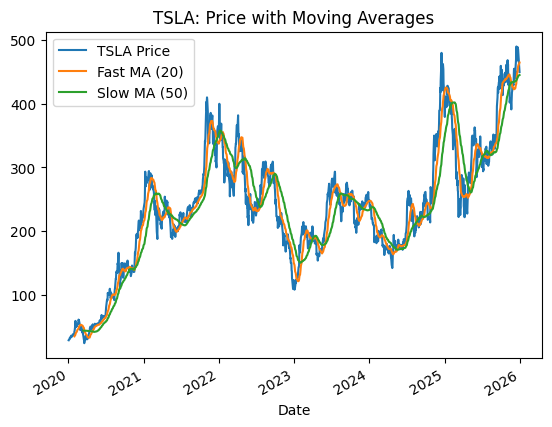

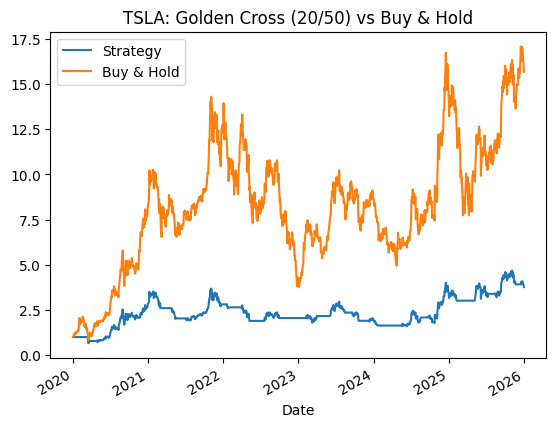

In [13]:
stock = 'TSLA'
price = df[stock].dropna()

fast = price.rolling(ma_fast).mean()
slow = price.rolling(ma_slow).mean()

# in the market whenever fast MA is above slow MA (golden cross regime),
# flat once it drops back below (death cross); shift(1) so we only act
# on the signal the day *after* the cross, avoiding lookahead bias
in_market = (fast > slow).astype(int)
position = in_market.shift(1).fillna(0)

returns = price.pct_change()
strategy_returns = position * returns

equity_curve = (1 + strategy_returns).cumprod()
buy_hold = (1 + returns).cumprod()

pd.DataFrame({
    f'{stock} Price': price,
    f'Fast MA ({ma_fast})': fast,
    f'Slow MA ({ma_slow})': slow,
}).plot(title=f'{stock}: Price with Moving Averages')

pd.DataFrame({'Strategy': equity_curve, 'Buy & Hold': buy_hold}).plot(
    title=f'{stock}: Golden Cross ({ma_fast}/{ma_slow}) vs Buy & Hold'
)

<Axes: title={'center': 'Portfolio: $100 per stock, Golden Cross (20/50)'}, xlabel='Date'>

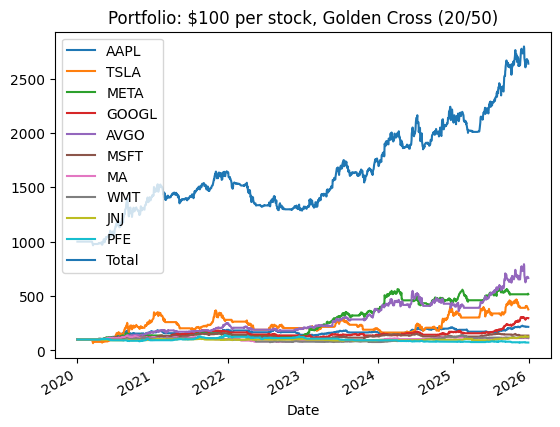

In [14]:
capital = 1000
allocation_per_stock = capital / 10  # each stock gets 1/10th of total capital

portfolio_value = pd.DataFrame(index=df.index)

for sym in ticker:
    price = df[sym]
    fast = price.rolling(ma_fast).mean()
    slow = price.rolling(ma_slow).mean()

    # each stock is traded independently on its own golden/death cross
    in_market = (fast > slow).astype(int)
    position = in_market.shift(1).fillna(0)

    strategy_returns = (position * price.pct_change()).fillna(0)
    portfolio_value[sym] = allocation_per_stock * (1 + strategy_returns).cumprod()

portfolio_value['Total'] = portfolio_value.sum(axis=1)

portfolio_value.plot(title=f'Portfolio: ${allocation_per_stock:.0f} per stock, Golden Cross ({ma_fast}/{ma_slow})')
